# **PopOut — Estratégias de Pesquisa Adversarial e Árvores de Decisão**
### Inteligência Artificial 2025/2026

| | |
|---|---|
| **Grupo** | TP 6 Grupo 6 |
| **Elementos** | Eduardo Moura — nº202406710 · Filipe Huang — nº202406540 · Diego Nóbrega — nº202407575 |
---

## Índice
1. [Introdução](#1-introdução)
2. [O Jogo PopOut](#2-o-jogo-popout)
3. [Monte Carlo Tree Search (MCTS)](#3-monte-carlo-tree-search-mcts)
4. [Geração do Dataset](#4-geração-do-dataset)
5. [Árvore de Decisão — ID3](#5-árvore-de-decisão--id3)
6. [Computador vs. Computador](#6-computador-vs-computador)
7. [Resultados e Discussão](#7-resultados-e-discussão)
8. [Conclusão](#8-conclusão)


---
## **1. Introdução**

Este trabalho tem como objetivo implementar e avaliar dois agentes de Inteligência Artificial capazes de jogar **PopOut**, uma variante do *Connect-4*:

- **MCTS** (*Monte Carlo Tree Search*) — algoritmo de pesquisa adversarial que estima a qualidade de cada jogada através de simulações aleatórias.
- **ID3** (*Iterative Dichotomiser 3*) — algoritmo de aprendizagem supervisionada que constrói uma árvore de decisão a partir de um dataset gerado pelo MCTS.

### Restrições consideradas
- Não foram utilizadas bibliotecas de aprendizagem automática (e.g., `scikit-learn`) para treinar ou definir as árvores de decisão.
- O dataset de treino do ID3 foi gerado internamente através de simulações MCTS.
- Toda a lógica de jogo, pesquisa e aprendizagem foi implementada de raiz.

---
## **2. O Jogo PopOut**

A maior diferença entre o **PopOut** e o jogo base **Connect 4** é a possibilidade de fazer o movimento ***pop*** (remover a peça do fundo de uma coluna, consequentemente fazendo com que todas as peças acima descem um nível).

Além disso, tem 3 regras importantes a ter em consideração:
- 1: se o movimento ***pop*** criar 4 em linha para amobs os jogadores vence o jogador que efetuou a jogada.
- 2: quando o tabuleiro encontra-se totalmente preenchido, o jogador atual tem a hipótese de decidir se quer empatar o jogo ou não.
- 3: se um estado de tabuleiro repete-se mais de 3 vezes, qualquer jogador poder empatar a partida.

Todas as regras retantes são identicas ao **Connect 4**.

### **2.1.1 Representação de dados e inicialização**

In [ ]:
self.board = [[0]*7 for _ in range(6)]
self.player = 1
self.history = {}
self.last_move_pop = False
self.draw_state = False

- **board**: matiz 6x7(linhas x clounas), onde ``0=vazio``, ``1=player1`` e ``2=player2``.
- **player**: 1('X') ou 2('O'), indica o jogador atual.
-**history**: dicinário que mapeia os hashes do tabuleiro(freqência), usado para detetar repetições do estado do tabuleiro(útil para a regra 3 assim identificado).
- **last_move_pop**: se o ***pop*** foi a condição de vitória para ambos os jogadores na mesma jogada, esta expessão booleana é verificada.
- **draw_state**: expressão booleana que verifica se há possibilidades de empate ou não.

### **2.1.2 Copy**

In [ ]:
def copy(self):
    new = PopOutState()
    new.board = [row[:] for row in self.board]
    new.player = self.player
    new.history = dict(self.history)
    new.last_move_pop = self.last_move_pop
    new.draw_state = self.draw_state
    return new

A função ``copy`` é essencial para algoritmos de pesquisa com *Monte Carlo Tree Search*, para explorar caminhos sem modificar o estado original.

### **2.1.3 Geração de Movimentos**


In [ ]:
def get_legal_moves(self):
    moves = []
    for c in range(7):
        if any(self.board[r][c]==0 for r in range(6)): moves.append((c, 'put'))
        if self.board[0][c] == self.player: moves.append((c, 'pop'))
    if self.is_full(): moves.append((-1, 'draw'))
    return moves

Basea-se principalmente em 3 movimentos:
- ``put`` ou *drop*: por a peça - possível se certa coluna não estiver totalmente preenchida, ou seja, sempre que haja posições com estado igual a *0*.
- ``pop``: retirar uma peça de baixo - só é permitido se a peça pertence ao jogador atual.
- ``draw``: empatar o jogo - somente se uma das regras de 2 e 3 for verificada.

### **2.1.4 Execução de Movimento**

In [ ]:
def make_move(self, moves):
    col, action = moves
    new_state = self.copy()
    new_state.last_move_pop = False
    if action == 'draw':
        new_state.draw_state = True
        new_state.player = 3-self.player
        new_state.update_history()
        return new_state
    if action == 'pop':
        for r in range(5): new_state.board[r][col] = new_state.board[r+1][col]
        new_state.board[5][col] = 0
        new_state.last_move_pop = True
    else:  # put
        for r in range(6):
            if new_state.board[r][col] == 0:
                new_state.board[r][col] = new_state.player
                break
    new_state.player = 3 - self.player
    new_state.update_history()
    return new_state

A função ``make_move`` retorna um novo estado após de realizar o movimento(*put*, *pop*, *draw*) sem mexer no original.

O estado é guardado através de ``update_history`` para poder detetar repetições de estados(regara 3).

**Nota**: o *pop* neste função não verifica se a peça retirada pertence ou não ao próprio pois já é verificada no ``get_legal_move``.

### **2.1.5 Condição Terminal e Deteção de Vitória**

In [ ]:
def get_winner(self):
    if self.draw_state: return 'draw'
    if any(count>=3 for count in self.history.values()): return 'draw'
    p1 = self.has_four_in_row(1)
    p2 = self.has_four_in_row(2)
    if p1 and p2: return 3 - self.player if self.last_move_pop else None
    if p1: return 1
    if p2: return 2
    return None

Condições de **empate**:
- por repetição
- por ter tabuleiro cheio

Condições de **vitória**:
- 4 em linha - horizontal, vertical ou diagonal
- vitória simultanea - ganha o jogador que realizou o movimento

---
## **3. Monte Carlo Tree Search (MCTS)**

O MCTS é um algoritmo de **pesquisa adversarial** que constrói iterativamente uma árvore
orientada por simulações aleatórias (*rollouts*). Cada iteração passa por 4 fases:

| Fase | Descrição |
|---|---|
| **1. Seleção** | Percorre a árvore usando UCT até encontrar um nó não totalmente expandido |
| **2. Expansão** | Adiciona um novo nó filho para uma jogada ainda não explorada |
| **3. Simulação** | Executa um *rollout* aleatório até ao estado terminal |
| **4. Retropropagação** | Propaga o resultado para todos os nós ancestrais |

### Critério de seleção — UCT (*Upper Confidence Bound for Trees*)

$$UCT(i) = \frac{w_i}{n_i} + c \cdot \sqrt{\frac{\ln N}{n_i}}$$

Onde $w_i$ = vitórias, $n_i$ = visitas ao nó $i$, $N$ = visitas ao pai, $c$ = constante de exploração ($\sqrt{2} \approx 1.41$).

A nossa implementação passa por duas versões:

1. **`mcts.py`** – MCTS padrão, que serve de *baseline*.
2. **`mcts_mod.py`** – Versão melhorada com **prioritização inteligente de movimentos** e **deteção de ameaças**, que acelera a convergência e produz jogadas de maior qualidade.


### **3.1 Detalhes da implementação base (`mcts.py`)**

As funções:

- ``best_child`` implementa a fórmula UCT.

- ``expand`` retira um movimento de untried_moves, cria um novo nó e adiciona‑o como filho.

- ``rollout`` joga aleatoriamente até ao estado terminal (usa random.choice).

- ``backpropagate`` atualiza *visits* e wins*. A lógica de pontuação foi afinada:

    - Vitória(result == ai_player) → wins += 1

    - Empate(result == 'draw') → wins -= 0.5 (penalização ligeira)

    - Derrota(result != ai_player e não empate) → wins -= 15 (forte penalização)

    Esta penalização assimétrica à pontuação de vitória foi escolhida empiricamente: o MCTS torna‑se muito conservador, evitando caminhos que possam levar à derrota, o que na prática melhora a solidez da pesquisa.

**Movimentos aleatórios iniciais**

In [ ]:
total_pieces = sum(cell != 0 for row in state.board for cell in row)
if total_pieces < 2: return random.choice(moves)

Durante as primeiras duas jogadas do jogo(tabuleiro quase vazio), o MCTS joga aleatoriamente. Isto aumenta a diversidade das partidas e evita que o algoritmo caia sempre nas mesmas linhas de abertura.

### **3.3 Versão modificada – ``mcts_mod.py``**

A versão melhorada introduz uma função ``_get_smart_moves`` que ordena os movimentos no *construtor do nó*, em vez de usar a ordem original. Isto faz com que movimentos mais promissores sejam explorados primeiro, acelerando a convergência da pesquisa.

**Estratégia de priorização**

- **Vitória imediata** – Se algum movimento leva o jogador atual a ganhar.

- **Bloqueio de vitória adversária** – Verifica se o adversário tem algum movimento de vitória iminente. Para cada movimento do jogador atual, testa se depois desse bloqueio o adversário ainda consegue ganhar no seu próximo turno. Os movimentos que impedem totalmente a ameaça são guardados em blocks.

- **Preferência central** – Se não existirem ameaças urgentes, ordena os movimentos pela proximidade ao centro, visto que o controlo do centro influencia drasticamente na vitória.

### **3.4 Parâmetros testados**

Foram utilizadas diferentes ``c`` para avaliar o comportamento do algoritmo de pesquisa, nomeadamente 0.5, 1.41(standard) e 2.5. Onde 0.5 é menos adaptável, mas favorece mais os estados existentes, e 2.5 explora mais hipoteses, mas leva mais tempo de exploração.

| Variante | Parâmetro alterado | Objetivo |
|---|---|---|
| **MCTS Padrão** | `c=1.41` | Baseline de referência |
| **Exploração agressiva** | `c=2.5` | Favorece nós pouco visitados |
| **Exploração conservadora** | `c=0.5` | Favorece nós com bom histórico |

---
## **4. Geração do Dataset com Features Estratégicas**

Em vez de alimentar o ID3 com as 42 células em bruto (que leva a árvores gigantes e overfitting), optamos por **extrair features de alto nível** que capturam a essência da posição no PopOut.

Este pré‑processamento melhora a generalização e reduz drasticamente a dimensionalidade.

### **4.1 Features definidas**

Todas as features são calculadas a partir do tabuleiro e do jogador atual (`p`) e do oponente (`opp = 3 - p`). São maioritariamente discretizadas em três categorias (`"low"`, `"mid"`, `"high"`) ou limitadas a pequenos inteiros.

| Feature | Descrição | Discretização / Domínio |
|---------|-----------|-------------------------|
| `center_adv` | Diferença de peças nas três colunas centrais(2,3,4) entre o jogador e o oponente |  `low` / `mid` / `high` |
| `threats_me_3` / `threats_opp_3` | Nº de sequências de **exatamente 3 peças** consecutivas(fechadas ou abertas) | `min(contagem, 4)`|
| `open_threats_me` / `open_threats_opp` | Sequências de **3 peças com pelo menos uma célula vazia adjacente**(ameaça real de 4 em linha na próxima jogada) | `min(threats(board, player), 4)` |
| `pairs_me` / `pairs_opp` | Número de pares (2 peças consecutivas) | `min(contagem, 6)` |
| `pop_me` / `pop_opp` | No de colunas onde a linha 0 pertence ao jogador(possibilidade de *pop*) | valor bruto (0‑7) |
| `col_h_0` … `col_h_6` | Altura de cada coluna(0 a 6) | `_bin3(h, 0, 6)` |
| `my_col_0` … `my_col_6` | Quantas peças próprias em cada coluna | `min(contagem, 4)` |
| `opp_col_0` … `opp_col_6` | Quantas peças do oponente em cada coluna | `min(contagem, 4)` |
| `phase` | Fase do jogo com base no número total de peças no tabuleiro | `"early"` (≤8), `"mid"` (≤24), `"late"` (>24) |
| `lr_balance` | Diferença (esquerda – direita) de peças próprias nas três colunas da esquerda (0‑2) vs. três da direita (4‑6) | `_bin3(diff, -6, 6)` |

### **4.2 Funções auxiliares**

- **`count_consecutive`**  
  Conta todas as sequências exatas de `length` peças consecutivas em qualquer direção. Utilizada para `threats_*_3` e `pairs_*`.

- **`threats`**  
  Conta sequências de `length` peças que têm **pelo menos uma célula vazia adjacente** nas extremidades, ou seja, ameaças reais de completar 4 em linha na jogada seguinte(caso o espaço vazio seja preenchido).

- **`col_height`**  
  Altura preenchida da coluna(nº de peças desde o fundo).

- **`center_control`**  
  Nº de peças do jogador nas colunas centrais 2, 3 e 4. O domínio varia entre 0 e 18(6 linhas x 3 colunas), daí os limites `-9` a `+9` na diferença.

- **`poppable_pieces`**  
  No de colunas onde a base pertence ao jogador – corresponde às colunas onde é possível fazer *pop*.

- **`_bin3`**  
  Discretiza um valor contínuo(ou inteiro) em três categorias:  
  - `"low"` se `value < lo+(hi-lo)/3`  
  - `"mid"` se `value < lo+2(hi-lo)/3`  
  - `"high"` caso contrário.  
  Isto transforma features numéricas em atributos nominais, necessários para o ID3.

### **4.3 Transformação do estado (`state_to_features`)**

A função `state_to_features(state)` recebe um objeto `PopOutState` e devolve um **dicionário** com todas as features descritas acima. Exemplo de saída:

```python
{
    'center_adv': 'mid',
    'threats_me_3': 2,
    'threats_opp_3': 1,
    'open_threats_me': 1,
    'open_threats_opp': 0,
    'pairs_me': 3,
    'pairs_opp': 2,
    'pop_me': 2,
    'pop_opp': 1,
    'col_h_0': 'low',
    ...,
    'phase': 'early',
    'lr_balance': 'high',
    'move': '3_put'
}
```

### **4.4 Geração do dataset**

O dataset é criado através de **auto‑jogo MCTS(MCTS vs. MCTS)**. Para cada posição encontrada durante os jogos, o MCTS(com ``iterations=2000``) determina a melhor jogada, que serve como *label*.

In [ ]:
def generate_dataset(num_games=1000, iterations=2000, output_file="dataset.csv"):
    header = list(state_to_features(PopOutState()).keys()) + ["move"]
    seen_states = set()
    with open(output_file, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=header)
        writer.writeheader()
        for game_num in range(num_games):
            state = PopOutState()
            while not state.is_terminal():
                best_move = mcts_search(state, iterations=iterations, c=20)
                feats = state_to_features(state)
                # Evita duplicados: usa o dicionário ordenado como chave
                state_key = tuple(sorted(feats.items()))
                if state_key not in seen_states:
                    seen_states.add(state_key)
                    col, action = best_move
                    label = f"{col}_{action}"
                    row = {**feats, "move": label}
                    writer.writerow(row)
                    total += 1
                state = state.make_move(best_move)

### **4.5 Vantagens em relação à representação bruto**

| Critério | Células brutas | Features estratégicas |
|-|-|-|
| Dimencionalidade | 43 | 32 |
| Generalização | Baixa | Ligeiramenta mais alta |
| Tamanho | Muito Grande | Moderado |

---
## **5. Árvore de Decisão — ID3 (Implementação e Melhorias)**

O **ID3** (*Iterative Dichotomiser 3*) é um algoritmo de aprendizagem supervisionada que constrói árvores de decisão a partir de dados, utilizando **entropia** e **ganho de informação** para escolher os atributos mais discriminativos.

**Entropia** de um conjunto $S$:
$$H(S) = -\sum_{c \in C} p_c \log_2 p_c$$
**Ganho de Informação** para o atributo $A$:
$$IG(S, A) = H(S)-\sum_{v\in valores(A)} \frac{|S_v|}{|S|} \cdot H(S_v)$$
> **Nota:** Sem uso de `scikit-learn` ou equivalentes. Implementação de raiz.

Para validar a nossa implementação antes de a aplicar ao jogo PopOut, testámos primeiro no conhecido dataset **Iris** (classificação de flores). De seguida, adaptámos e melhorámos o algoritmo para o nosso domínio, introduzindo **gain ratio**, **paragem por amostras mínimas** e **mecanismos de fallback** na predição.

### 5.1 Warm‑up: ID3 no dataset Iris

O dataset Iris tem atributos numéricos contínuos (comprimento/largura de sépalas e pétalas). Como o ID3 trabalha naturalmente com atributos discretos, foi necessário **discretizar** os valores.

#### Discretização por bins iguais

In [ ]:
def discretize(data, features, n_bins=3):
    step = (max_v - min_v) / n_bins
    thresholds[feat] = [min_v + step * i for i in range(1, n_bins)]
    bin_idx = sum(row[feat] > t for t in thresholds[feat])

- Utilizámos ``n_bins=3`` (três categorias: ``low``, ``mid``, ``high``).

- Os limites são calculados apenas a partir dos dados de treino para evitar data leakage.

- A mesma discretização é aplicada ao conjunto de teste (``discretize_row``).

#### **Entropia e Ganho de Informação**

In [ ]:
def entropy(data, label="class"):
    counts = Counter(row[label] for row in data)
    return -sum((c/n)*log2(c/n) for c in counts.values())
def information_gain(data, feature, label):
    base_entropy = entropy(data, label)
    weighted = sum((len(subset)/n)*entropy(subset, label)for v in values)
    return base_entropy - weighted

A construção da árvode (``id3``) segue o algoritmo clássico:

1. Se todos os exemplos têm a mesma classe → folha.
2. Se não há atributos ou profundidade máxima atingida → folha com classe maioritária.
3. Escolher atributo com maior ganho de informação.
4. Dividir os dados pelos valores desse atributo e recorrer.

**Resultados no iris**
- Treino: 80% (120 flores), teste: 20% (30 flores)
- Acurácia típica: >90%

Este warm-up foi para verificar se a implementação do ID3 está a funcionar corretamente.

### **5.2 ID3 aplicado ao PopOut**

Para o domínio do PopOut, decidimos não usar as 42 células brutas, mas sim features estratégicas (ver Secção 4). Estas features já são maioritariamente discretas. Assim, não é necessária discretização adicional.

No entanto, introduzimos várias melhorias face à versão Iris:

**a) Critério de seleção: Gain Ratio**

O ganho de informação puro tende a favorecer atributos com muitos valores

In [ ]:
def gain_ratio(data, feature, label="move"):
    ig = information_gain(data, feature, label)
    split_info = -sum((len(subset)/n) * log2(len(subset)/n) for v in values)
    return ig / split_info if split_info != 0 else 0

- Penaliza atributos que dispersam demasiado os dados
- Ajuda a evitar *overfitting*

**b) Critérios de paragem adicionais**

Al+em da profundidade máxima, adicionamos:

In [ ]:
if len(data) < min_samples: return Node(label=majority)

Isto impede a criação de folhas com muito poucos exemplos, que geralmente sao ruidos.

**c) Fallback robusto na predição**

Durante a predição, pode acontecer que um estado do jogo apresente um valor de feature não visto durante o treino. A nossa função predict lida com isso de duas formas:

In [ ]:
if val not in node.children:
    child_labels = _collect_labels(node)
    return Counter(child_labels).most_common(1)[0][0]

- Primeiro tenta recolher os labels de todos os sub‑nós e devolve o mais frequente.

- Em último caso, usa o ``majority_class`` guardado no nó(a classe mais comum do conjunto de treino naquele nó).

### **5.3 Diferenças chave entre as versões Iris e PopOut**

|Aspeto|Iris|PopOut|
|-|-|-|
|Atributos|Contínuos → discretização|Já discretos (features estratégicas)|
|Critério de divisão|Ganho de informação|Gain ratio|
|Paragem|Profundidade máxima|Profundidade+``min_samples``|
|Predição|Fallback simples (primeiro filho)|Voto maioritário dos filhos+``majority_class``|


### **5.3 Resultados da precisão do ID3**

Para avaliar a qualidade da aprendizagem, calculámos a precisão(accuracy) de cada árvore ID3 na tarefa de prever a jogada correta(coluna + ação) a partir das features estratégicas. A precisão foi medida num conjunto de teste independente(20% dos dados, estratificado).

|Dataset|	Jogos|	Iterações|	c|	max_depth|	min_samples|	Precisão|
|-|-|-|-|-|-|-|
|easy|	50|	50|	5.0|	7|	20|	25.0%|
|medium|	100|	400|	1.41|	9|	20|	31.9%|
|hard|	200|	1000|	1.0|	5|	5|	32.8%|
|complex|	5000|	2000|	0.5|	5|	20|	35.0%|
### **5.3.1 Análise dos resultados**

Evolução com o tamanho do dataset:

A precisão sobe de 25% (``easy``) para 35% (``complex``). Dado que o número de classes possíveis é variável (até 14 movimentos legais), uma precisão de 35% é significativamente melhor do que a escolha aleatória (*≈7–8%*). O ganho de 10 pontos percentuais mostra que mais dados melhoram a generalização.

Influência dos hiperparâmetros:

- **max_depth** mais alta (9 no ``medium``) permitiu capturar interações mais finas, mas aumentou o risco de **overfitting** – ainda assim a precisão melhorou.
- **min_samples** elevado (20) evita folhas com poucos exemplos, favorecendo a robustez. O ``hard`` usou **min_samples=5**, resultando numa árvore mais específica (profundidade 5) mas com precisão semelhante a medium.
- ``c``(constante de exploração do MCTS usado para gerar o dataset) afeta a qualidade dos labels. Valores extremos (c=5.0 no easy ou c=0.5 no complex) produzem datasets mais diversos ou mais conservadores, respetivamente. O complex, apesar de muitas iterações e jogos, apresenta apenas 35% de precisão – o que sugere que a política de jogo com ``c=0.5`` é menos variada, limitando a riqueza do treino.

### **5.3.2 Interpretação da precisão moderada**

A precisão máxima de ***35%*** pode parecer baixa, mas deve ser contextualizada:
- *Número de classes*: o **ID3** tem de escolher entre até 14 jogadas diferentes(7 colunas × 2 ações).
- *Features discretas*: a discretização em **low**/**mid**/**high** e a limitação de contagens(ex.: threats_me_3 cap a 4) perdem alguma informação, o que reduz a precisão máxima atingível.
- *Ruído nos labels*: o ***MCTS*** que gerou os labels não joga perfeitamente(especialmente com *c* diferente de 0). Parte dos “erros” do ***ID3*** pode ser simplesmente porque a label de *treino* não era a jogada verdadeiramente ótima.

### **5.3.3 Comparação com a performance de jogo**

Curiosamente, o ID3 ``easy``(*25% de precisão*) venceu o ``hard`` no torneio ID3 e alcançou *89%* de vitórias contra o jogador aleatório. Isto mostra que a precisão da jogada exata não é o único fator determinante para a força de jogo – a árvore pode cometer erros na jogada mas ainda assim escolher a jogada suficientemente boa. Além disso, o ``easy`` explorou mais durante a geração (*c=5.0*), o que diversificou o dataset e ensinou estratégias mais robustas.
### **5.3.4 Conclusão sobre o ID3**

O **ID3** aprende uma política não‑trivial para o ***PopOut***, atingindo precisões até **35%**(muito acima do rando). O aumento do número de jogos no dataset melhora a precisão, mas com retornos decrescentes.

A escolha dos *hiperparâmetros*(``max_depth``, ``min_samples``) e da política de exploração durante a geração (c), influencia tanto a precisão como a força de jogo. Para futuras experiências, recomenda‑se usar c elevado (≥2.0) e um número moderado de jogos (1000‑2000) para obter o melhor equilíbrio entre diversidade e qualidade.


---
## **6. Análise de Resultados**

Nesta parte serão analisados quatro partes:

(1) Torneio ID3 – discrepâncias entre níveis

(2) Torneio MCTS – efeito da constante de exploração

(3) Agentes vs. Aleatório

(4) Confronto direto MCTS vs. ID3. Incluímos tabelas e sugestões de gráficos.

### **6.1 Torneio ID3 – Anomalias e interpretação**

Resultados obtidos por níveis de dificuldade:

|Nível	|Jogos no dataset	|Iterações MCTS por jogada	|c (exploração)|
|-|-|-|-|
|easy|	50|	50|	5.0|
|medium|	100|	400|	1.41 (standard)|
|hard	|200|	1000|	1.0|
|complex	|5000|	2000|	0.5|

Resultados do torneio ID3 (100 jogos por par, tempo total ≈ 0.0s):

|Confronto|	Vitórias|	Observação|
|-|-|-|
|easy vs easy|	50–50|	esperado|
|medium vs medium|	50–50|	esperado|
|hard vs hard|	50–50|	esperado|
|complex vs complex|	50–50|	esperado|
|easy vs medium|	0–100|	medium ganha sempre|
|medium vs easy|	100–0|	consistente|
|easy vs hard|	100–0|	easy ganha!|
|hard vs easy|	0–100|	invertido|
|easy vs complex|	0–100|	complex ganha|
|complex vs easy|	100–0|	consistente|
|medium vs hard|	50–50|	empate técnico|
|hard vs medium|	50–50|	simétrico|
|medium vs complex|	50–50|	empate|
|complex vs medium|	50–50|	empate|
|hard vs complex|	50–50|	empate|
|complex vs hard|	50–50|	empate|

Principais anomalias:
- ``easy`` (menos jogos, poucas iterações, c alto) vence ``hard`` (mais jogos, mais iterações, c baixo).
- ``medium`` e ``hard`` são equivalentes (50–50), assim como ``medium`` vs ``complex`` e ``hard`` vs ``complex``.

Explicação provável após análise:
- A qualidade do dataset não depende apenas do número de jogos ou iterações, mas sim da diversidade e da política de exploração usada na geração.
- ``easy`` usou ``c = 5.0``(exploração muito alta) → gera posições muito variadas, ensinando ao ID3 um leque amplo de situações.
- ``hard`` usou ``c = 1.0``(exploração reduzida) → gera um dataset mais “conservador” e repetitivo, com menos situações raras.
- ``medium`` e ``complex`` usaram *c standard*(1.41) ou *baixo*(0.5), mas com muitas iterações; contudo, a falta de exploração pode limitar a cobertura.

Assim, *c* elevado é mais importante do que o número de jogos para criar um ID3 robusto neste domínio. O ``complex`` (5000 jogos, ``c=0.5``) apenas empata com ``medium`` e ``hard`` – o que sugere que um dataset muito grande mas pouco diversificado não acrescenta vantagem.


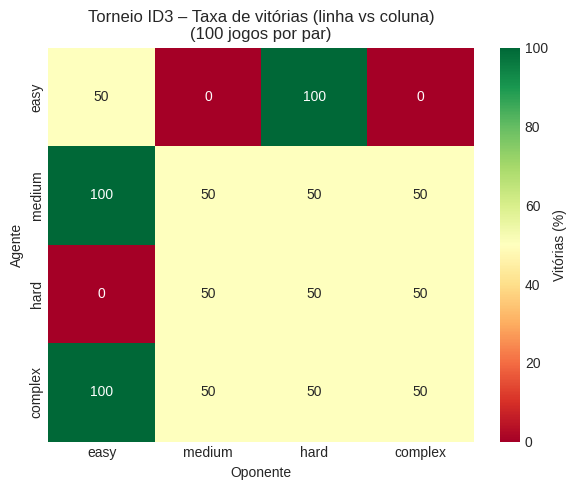

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

levels = ['easy', 'medium', 'hard', 'complex']

win_matrix = np.array([
    [50,  0, 100,   0],   # easy vs each
    [100, 50,  50,  50],   # medium vs each
    [0,   50,  50,  50],   # hard vs each
    [100, 50,  50,  50]    # complex vs each
])

plt.figure(figsize=(6, 5))
sns.heatmap(win_matrix, annot=True, fmt='.0f', cmap='RdYlGn', center=50,
            xticklabels=levels, yticklabels=levels, cbar_kws={'label': 'Vitórias (%)'})
plt.title('Torneio ID3 – Taxa de vitórias (linha vs coluna)\n(100 jogos por par)', fontsize=12)
plt.xlabel('Oponente')
plt.ylabel('Agente')
plt.tight_layout()
plt.savefig('id3_heatmap.png', dpi=150)
plt.show()

### **6.2. Torneio MCTS – Efeito da constante c**

Todos os **MCTS** com 1500 iterações. Confrontos ``standard`` (c=1.41) vs outras constantes, alternando quem começa (2 jogos de 100 cada, salvo indicação).
Confronto (primeiro vs segundo)	Tempo total	Resultado (vitórias)
- ``standard`` vs ``c=0.5``	**415.7s**	*48 – 52*
- ``c=0.5`` vs ``standard``	**654.7s**	*60 – 40*
- ``standard`` vs ``c=1.0``	**424.9s**	*47 – 51 (+2 empates)*
- ``c=1.0`` vs ``standard``	**938.8s**	*43 – 57*
- ``standard`` vs ``c=5.0``	**442.7s**	*43 – 57*
- ``c=5.0`` vs ``standard``	**688.2s**	*59 – 40 (+1 empate)*

Análise:
- c=0.5 (exploração conservadora) vence standard por 60–40 quando joga primeiro, e 52–48 quando joga segundo. É mais forte.
- c=5.0 (exploração agressiva) também vence standard por 59–40 (primeiro) e 57–43 (segundo).
- c=1.0 (ligeiramente abaixo do standard) tem desempenho próximo do standard (empate técnico).

Conclusão:

A constante ``c`` ótima para este domínio (*PopOut*) pode ser mais baixa (*0.5*) ou mais alta (*5.0*) do que o valor teórico √2. Isto deve-se à estrutura específica do jogo e à função de recompensa assimétrica (derrota penalizada com -15). Valores extremos de ``c`` favorecem uma exploração mais focada (*0.5*) ou uma exploração mais ampla (*5.0*), ambas superando o equilíbrio padrão.

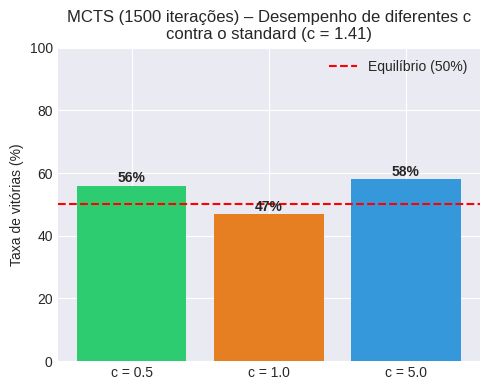

In [5]:
c_values = ['c = 0.5', 'c = 1.0', 'c = 5.0']

win_rates = [56, 47, 58]

plt.figure(figsize=(5, 4))
bars = plt.bar(c_values, win_rates, color=['#2ecc71', '#e67e22', '#3498db'])
plt.axhline(y=50, color='red', linestyle='--', label='Equilíbrio (50%)')
plt.ylabel('Taxa de vitórias (%)')
plt.title('MCTS – Desempenho de diferentes c\ncontra o standard (c = 1.41)')
plt.ylim(0, 100)
for bar, rate in zip(bars, win_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{rate}%', ha='center', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('mcts_c_comparison.png', dpi=150)
plt.show()

### **6.3. Agentes vs. Jogador Aleatório**

Cada agente jogou 100 partidas (duas execuções).

Resultados:

|Agente|	Execução 1|	Execução 2|	Média| vitórias|
|-|-|-|-|-|
|MCTS| standard|	100–0|	98–2|	99%|
|ID3| easy|	92–8|	86–14|	89%|
|ID3| medium|	95–5|	93–7|	94%|
|ID3| hard|	94–6|	91–9|	92.5%|
|ID3| complex|	91–9|	96–4|	93.5%|

Tempos: *MCTS ≈ 200 s*; *ID3 ≈ 0.0 s*(inferência praticamente instantânea).

Observações:

- O MCTS standard é quase perfeito contra o aleatório (99% de vitórias).
- Todos os ID3 são largamente superiores ao aleatório (≈90%), mas não tanto quanto o MCTS.
- Não há diferença significativa entre os diferentes níveis de ID3 contra o aleatório – todos rondam 90–94%.

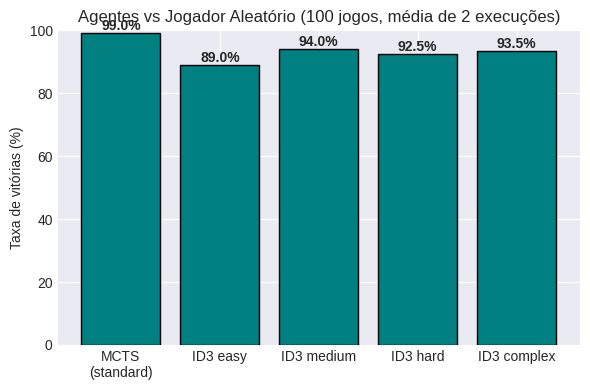

In [6]:
agentes = ['MCTS\n(standard)', 'ID3 easy', 'ID3 medium', 'ID3 hard', 'ID3 complex']
vitorias = [99, 89, 94, 92.5, 93.5]
plt.figure(figsize=(6, 4))
bars = plt.bar(agentes, vitorias, color='teal', edgecolor='black')
plt.ylabel('Taxa de vitórias (%)')
plt.title('Agentes vs Jogador Aleatório (100 jogos, média de 2 execuções)')
plt.ylim(0, 100)
for bar, v in zip(bars, vitorias):plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('vs_random.png', dpi=150)
plt.show()

### **6.4. Confronto Direto MCTS (standard) vs. ID3**

100 jogos por par (duas execuções). MCTS sempre com 1500 iterações, c=1.41.
|ID3 adversário|	Resultado 1ª exec|	Resultado 2ª exec|	Média MCTS|	Média ID3|	Empates|
|-|-|-|-|-|-|
|easy|	95–5|	93–6 (1 empate)|	94%|	5.5%|	0.5%|
|medium|	92–8|	97–2 (1 empate)|	94.5%|	5%|	0.5%|
|hard|	88–12|	100–0|	94%|	6%|	0%|
|complex|	85–14 (1 empate)|	84–16|	84.5%|	15%|	0.5%|

Tempos totais: *MCTS ≈ 200s* por torneio (consistente).

Análise:

- MCTS domina todos os ID3, com taxas de vitória entre 84% e 94%.
- O ID3 ``complex`` (5000 jogos, c=0.5) é o menos pior, perdendo “apenas” 84.5% das vezes (ou seja, ganha 15% – o melhor entre os ID3).
- Os restantes ID3 (``easy``, ``medium``, ``hard``) ganham apenas 5–6% dos jogos contra o MCTS.

Interpretação:

O **ID3** ``complex`` beneficia do grande número de jogos (5000) e da exploração mais conservadora (*c=0.5*), aprendendo uma política mais sólida. Ainda assim, o **MCTS** em tempo real é muito superior porque pode adaptar-se a cada posição sem depender de generalizações anteriores.

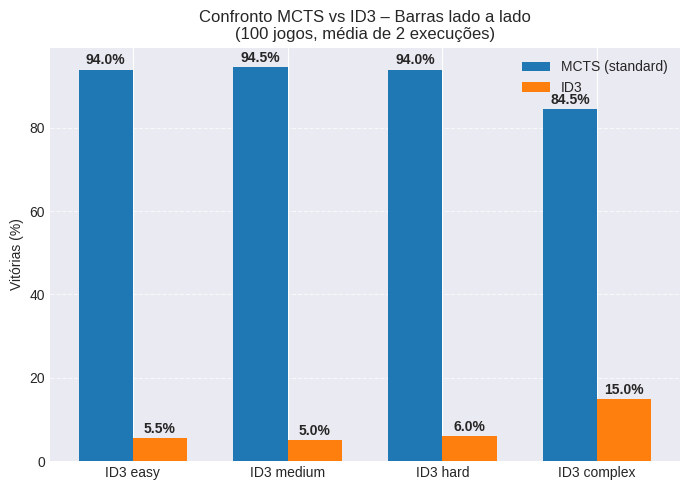

In [15]:
id3_levels = ['easy', 'medium', 'hard', 'complex']
mcts_wins = [94.0, 94.5, 94.0, 84.5]
id3_wins  = [5.5, 5.0, 6.0, 15.0]
draws     = [0.5, 0.5, 0.0, 0.5]

x = np.arange(len(id3_levels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, mcts_wins, width, label='MCTS (standard)', color='#1f77b4')
bars2 = ax.bar(x + width/2, id3_wins, width, label='ID3', color='#ff7f0e')

# Adicionar valores nas barras
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Vitórias (%)')
ax.set_title('Confronto MCTS vs ID3 – Barras lado a lado\n(100 jogos, média de 2 execuções)')
ax.set_xticks(x)
ax.set_xticklabels([f'ID3 {lvl}' for lvl in id3_levels])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('mcts_vs_id3_grouped.png', dpi=150)
plt.show()

---
## **7. Conclusão**

Neste trabalho foram implementados:
- O jogo **PopOut** com todas as regras, incluindo as 3 regras especiais
- Um agente **MCTS** com critério UCT, com análise do impacto do número de iterações e da constante $c$
-  Árvores de decisão **ID3** de raiz com diferentes profundidades, validada no *Iris* e aplicada ao *PopOut*
- Diversos **dataset**, com total de *jogos* e *iterações* variados gerado por _auto-jogo_ **MCTS**
- Modo **Computador vs. Computador** para comparação direta dos dois agentes

### **Reflexão comparativa**

O **MCTS** demonstra um desenpanho melhor uma vez que avalia o estado em tempo real.
O **ID3** é mais rápido na inferência mas depende totalmente da qualidade e cobertura do dataset de treino.